In [3]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
frame='021D_05266_252525'
# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

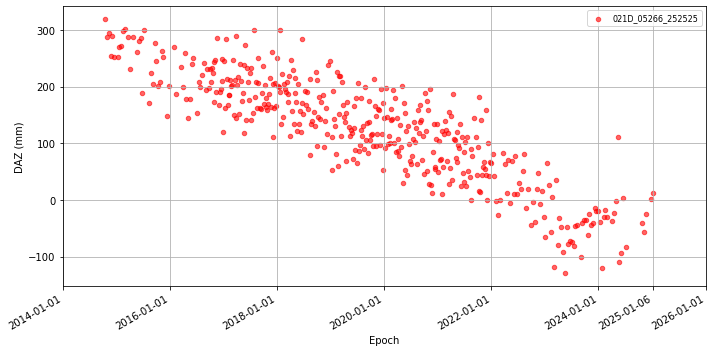

In [4]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], dazes['daz'], color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Defau ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

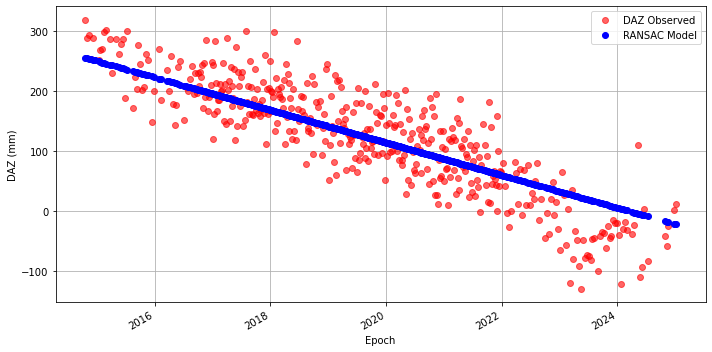

In [5]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
# Convert epoch to numeric time in days
df_daz=dazes.copy()
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)  # model prediction for all dates

# Plot DAZ and DAZ model
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_daz['epoch'], df_daz['daz'], 'o', color='red', alpha=0.6, label='DAZ Observed')
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], 'o', color='blue', label='RANSAC Model')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

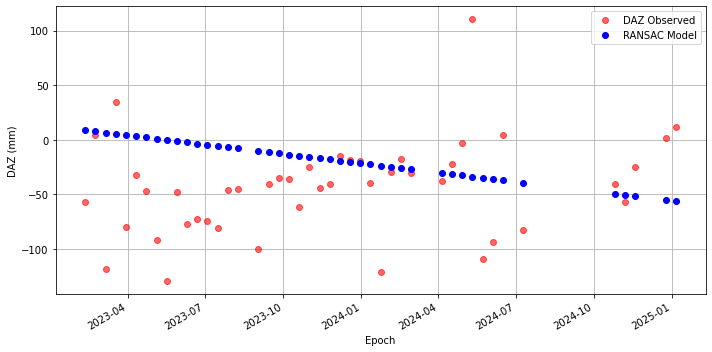

In [7]:
import matplotlib.dates as mdates

# Define cutoff date
cutoff_date = pd.to_datetime("2023-02-06")

# Filter for post-earthquake dates
df_plot = df_daz[df_daz['epoch'] > cutoff_date]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_plot['epoch'], df_plot['daz'], 'o', color='red', alpha=0.6, label='DAZ Observed')

if 'daz_model' in df_plot:
    ax.plot(df_plot['epoch'], df_plot['daz_model'], 'o', color='blue', label='RANSAC Model')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


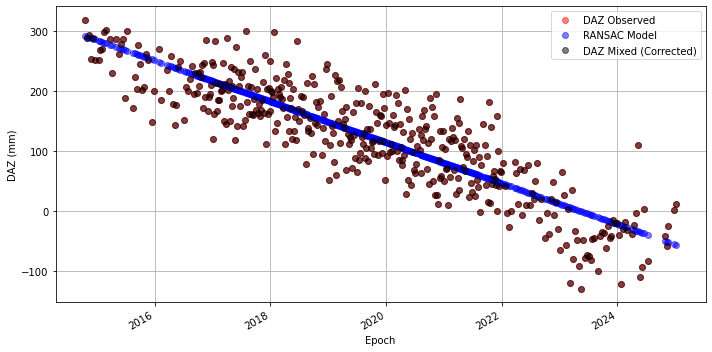

In [6]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.pyplot as plt

# Convert epoch to numeric time in days
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
    df_daz['daz_mixed'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)

    # Replace DAZ values with model if the difference > threshold (250 mm)
    # threshold = 250
    # diff = np.abs(df_daz['daz'] - df_daz['daz_model'])
    # df_daz['daz_mixed'] = np.where(diff > threshold, df_daz['daz_model'], df_daz['daz'])
    threshold = 250
    adjustment = 350
    diff = np.abs(df_daz['daz'] - df_daz['daz_model'])
    
    df_daz['daz_mixed'] = df_daz['daz']  # initialize with original values
    
    # Apply custom correction
    mask_large_diff = diff > threshold
    df_daz.loc[mask_large_diff & (df_daz['daz'] > df_daz['daz_model']), 'daz_mixed'] -= adjustment
    df_daz.loc[mask_large_diff & (df_daz['daz'] < df_daz['daz_model']), 'daz_mixed'] += adjustment
    

    

# Plot DAZ (original), model, and mixed
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_daz['epoch'], df_daz['daz'], 'o', color='red', alpha=0.5, label='DAZ Observed')
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], 'o', color='blue', alpha=0.5, label='RANSAC Model')
if 'daz_mixed' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_mixed'], 'o', color='black', alpha=0.5,label='DAZ Mixed (Corrected)')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [9]:
import os
import numpy as np
from lics_unwrap import *
from datetime import datetime

setting pyproj data directory


In [15]:
abs_file='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/try-option4-050825/absolute/021D_05266_252525/TS_GEOCml10mask/cum.h5'
cumh5 = h5.File(abs_file,'r')
imdates = cumh5['imdates'][()].astype(str).tolist()
cum = cumh5['cum']
n_im, length, width = cum.shape
cuma = xr.load_dataset(abs_file)

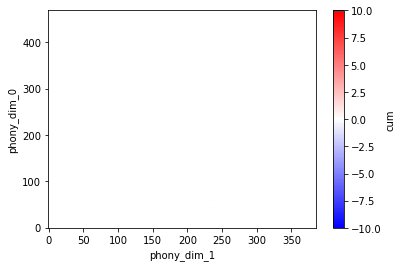

In [19]:
cuma['cum'][0].plot(cmap='bwr',vmin=-10, vmax=10)